In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition  import PCA

file_1 = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_scaled.csv"
rfm_scaled = pd.read_csv(file_1)

file_2 = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_KMeans.csv"
rfm = pd.read_csv(file_2)

Varianza explicada por PC1: 75.58%
Varianza explicada por PC2: 18.60%
Varianza total explicada (2D): 94.17%


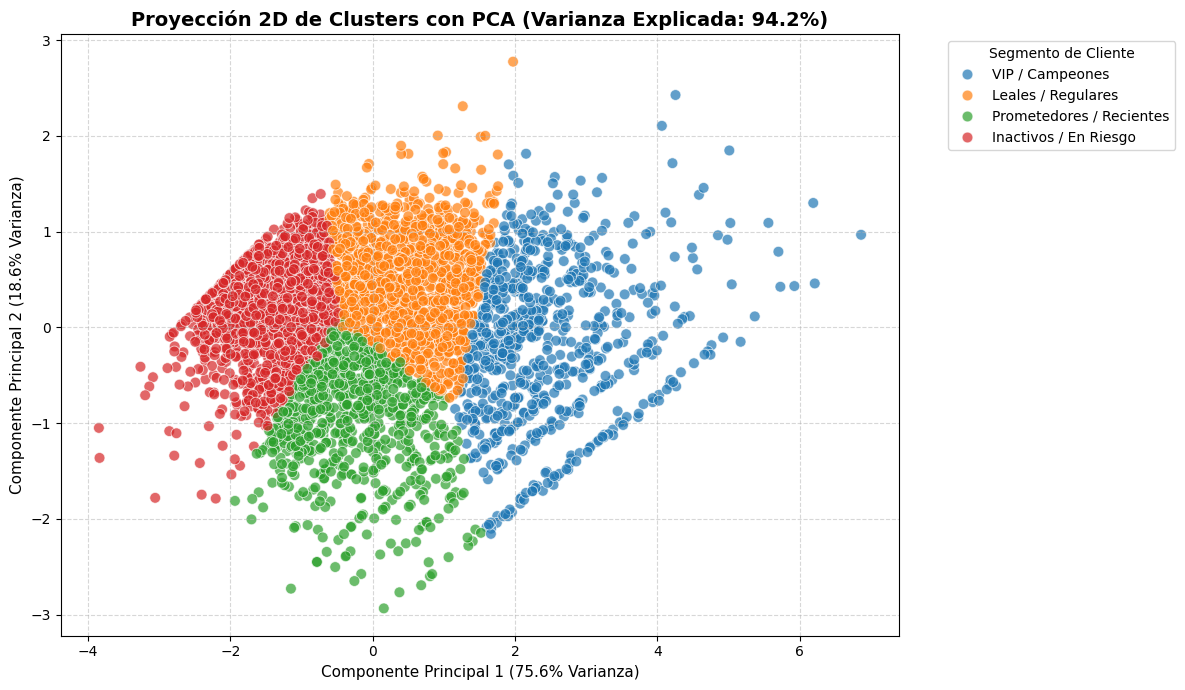

In [3]:
# 1. Seleccionar solo las variables numéricas escaladas (sin etiquetas ni IDs)
X = rfm_scaled[['Recency', 'Frequency', 'Monetary']]

# 2. Inicializar y entrenar PCA para reducir a 2 componentes
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X)

# 3. Crear DataFrame con los componentes principales
rfm_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
rfm_pca['Cluster_Name'] = rfm['Cluster_Name']
rfm_pca['Cluster'] = rfm['Cluster']

# Calcular la varianza explicada por los 2 componentes
var_explicada = pca.explained_variance_ratio_
total_var = var_explicada.sum() * 100

print(f"Varianza explicada por PC1: {var_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_explicada[1]*100:.2f}%")
print(f"Varianza total explicada (2D): {total_var:.2f}%")

# 4. Graficar los Clusters en el espacio 2D de PCA
plt.figure(figsize=(12, 7))

# Orden y paleta coherente con la gráfica anterior
segment_order = [
    "VIP / Campeones",
    "Leales / Regulares",
    "Prometedores / Recientes",
    "Inactivos / En Riesgo"
]

sns.scatterplot(
    data=rfm_pca,
    x='PC1',
    y='PC2',
    hue='Cluster_Name',
    hue_order=segment_order,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    alpha=0.7,
    s=60
)

plt.title(f'Proyección 2D de Clusters con PCA (Varianza Explicada: {total_var:.1f}%)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}% Varianza)', fontsize=11)
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}% Varianza)', fontsize=11)
plt.legend(title='Segmento de Cliente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
rfm_pca.to_csv(r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_PCA", index=False)
print("¡Reporte 'Clientes por Segmento (RFM + PCA)' en data/processed/rfm_PCA.csv!")

¡Reporte 'Clientes por Segmento (RFM + PCA)' en data/processed/rfm_PCA.csv!
